 # 🎯 Capstone: Klasifikasi Diabetes dengan Deep Learning
 **Dataset**: `diabetes_prediction_dataset.csv` | **Target**: `diabetes` (0/1)

In [ ]:
# Fase 0 — Install & Import
import subprocess, sys
for pkg in ['imbalanced-learn','lightgbm','xgboost']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])

In [ ]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
import tensorflow as tf, warnings, gc, os, json, joblib, datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score, mean_absolute_error)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import EditedNearestNeighbours, TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek
from tempfile import mkdtemp
from shutil import rmtree
warnings.filterwarnings('ignore')

 ---
 ## Fase 1 — Data Wrangling
 ### 1.1 Gathering Data

In [ ]:
data = pd.read_csv("diabetes_prediction_dataset.csv")
print(f"Dataset shape: {data.shape}")
print(f"Sumber: Kaggle - Diabetes Prediction Dataset")
data.head(10)

Dataset shape: (100000, 9)
Sumber: Kaggle - Diabetes Prediction Dataset


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


 ### 1.2 Assessing Data

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
print("=== Missing Values ===")
print(data.isnull().sum())
print(f"\n=== Duplikat: {data.duplicated().sum()} baris ===")

=== Missing Values ===
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

=== Duplikat: 3854 baris ===


In [ ]:
# Cek outlier (IQR) pada fitur numerik
for col in ['age','bmi','HbA1c_level','blood_glucose_level']:
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    out = ((data[col] < Q1-1.5*IQR) | (data[col] > Q3+1.5*IQR)).sum()
    print(f"{col}: {out} outliers")

age: 0 outliers
bmi: 7086 outliers
HbA1c_level: 1315 outliers
blood_glucose_level: 2038 outliers


 ### 1.3 Cleaning Data

In [ ]:
data.drop_duplicates(inplace=True)
print(f"Shape setelah hapus duplikat: {data.shape}")

Shape setelah hapus duplikat: (96146, 9)


In [ ]:
gender_map = {'Female': 0, 'Male': 1, 'Other': 2}
smoking_map = {'never': 0, 'No Info': 1, 'current': 2, 'former': 3, 'ever': 4, 'not current': 5}
data['gender'] = data['gender'].map(gender_map)
data['smoking_history'] = data['smoking_history'].map(smoking_map)
print("Encoding kategorikal selesai.")

Encoding kategorikal selesai.


 ### 1.4 Data Dictionary
 | Kolom | Tipe | Keterangan |
 |---|---|---|
 | gender | int | 0=Female, 1=Male, 2=Other |
 | age | float | Usia pasien |
 | hypertension | int (0/1) | Riwayat hipertensi |
 | heart_disease | int (0/1) | Riwayat penyakit jantung |
 | smoking_history | int | 0=never..5=not current |
 | bmi | float | Body Mass Index |
 | HbA1c_level | float | Kadar HbA1c |
 | blood_glucose_level | int | Kadar glukosa darah |
 | **diabetes** | **int (0/1)** | **TARGET** |

 ---
 ## Fase 2 — Exploratory Data Analysis (EDA)

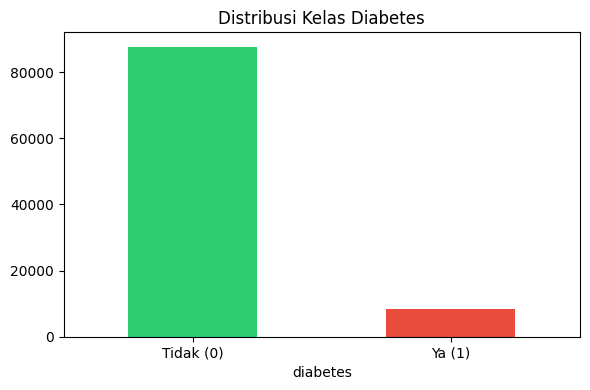

diabetes
0    0.91178
1    0.08822
Name: proportion, dtype: float64


In [ ]:
# Distribusi target (class imbalance check)
fig, ax = plt.subplots(figsize=(6,4))
data['diabetes'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], ax=ax)
ax.set_title('Distribusi Kelas Diabetes'); ax.set_xticklabels(['Tidak (0)','Ya (1)'], rotation=0)
plt.tight_layout(); plt.show()
print(data['diabetes'].value_counts(normalize=True))

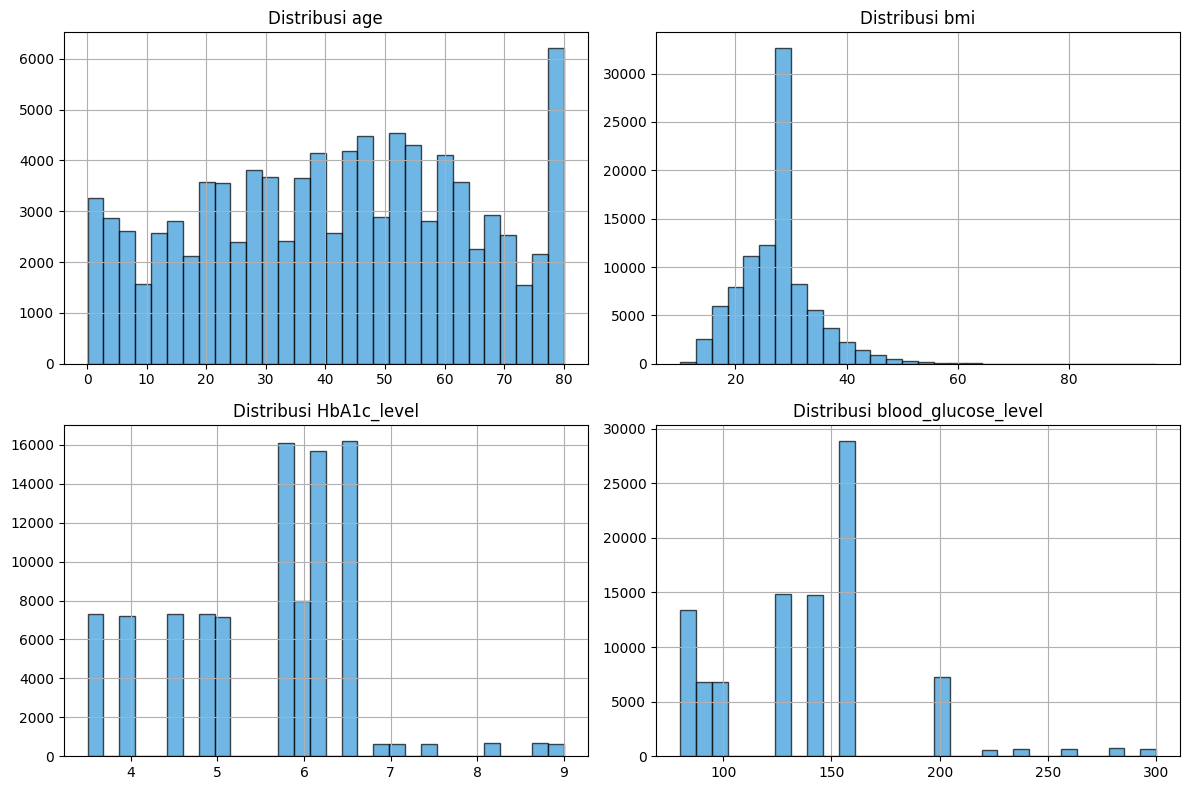

In [ ]:
# Distribusi fitur numerik
fig, axes = plt.subplots(2,2, figsize=(12,8))
for ax, col in zip(axes.flatten(), ['age','bmi','HbA1c_level','blood_glucose_level']):
    data[col].hist(bins=30, ax=ax, color='#3498db', alpha=0.7, edgecolor='black')
    ax.set_title(f'Distribusi {col}')
plt.tight_layout(); plt.show()

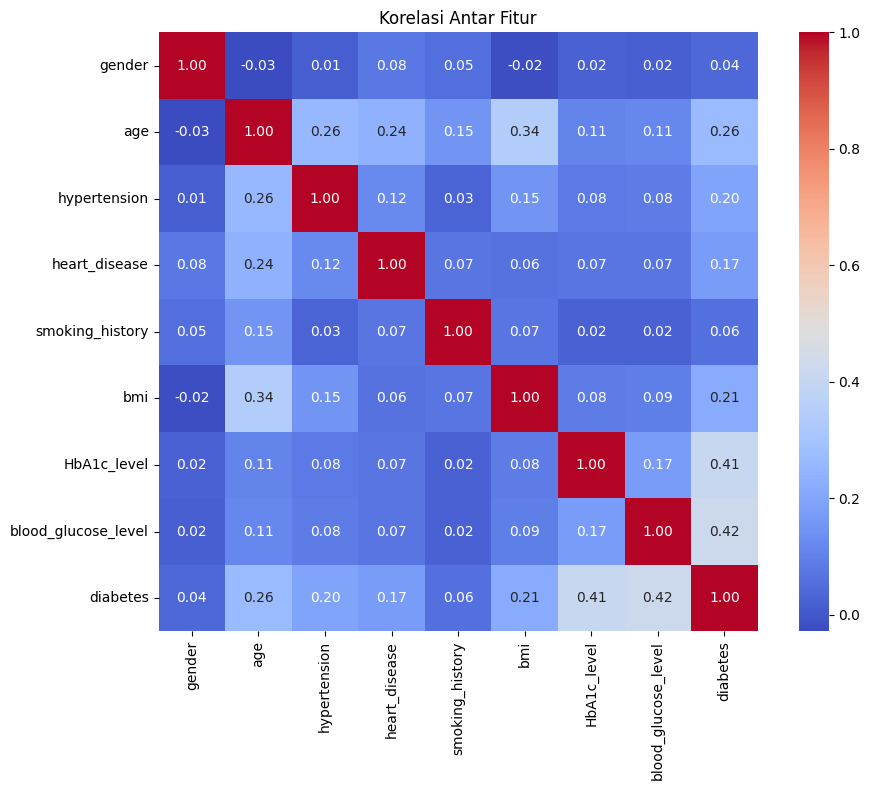

In [ ]:
# Korelasi heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Korelasi Antar Fitur'); plt.tight_layout(); plt.show()

 ### Pertanyaan Bisnis:
 1. Apakah BMI tinggi meningkatkan risiko diabetes?
 2. Bagaimana pengaruh usia terhadap diabetes?
 3. Apakah hipertensi berkorelasi dengan diabetes?

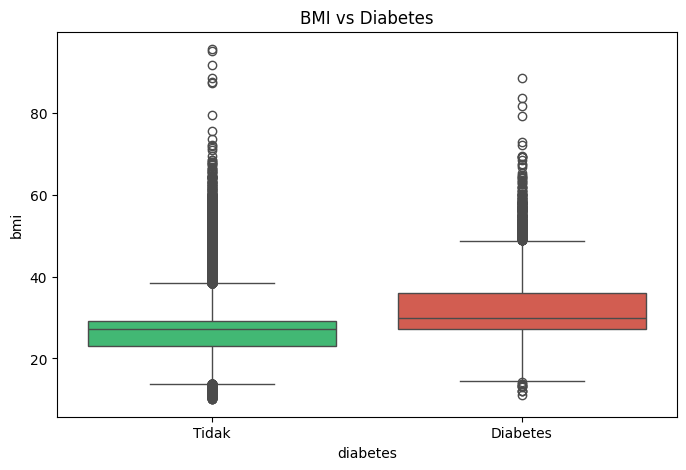

BMI rata-rata: Non-DM=26.9, DM=32.0


In [ ]:
# Q1: BMI vs Diabetes
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(x='diabetes', y='bmi', data=data, palette=['#2ecc71','#e74c3c'], ax=ax)
ax.set_title('BMI vs Diabetes'); ax.set_xticklabels(['Tidak','Diabetes'])
plt.show()
print(f"BMI rata-rata: Non-DM={data[data.diabetes==0].bmi.mean():.1f}, DM={data[data.diabetes==1].bmi.mean():.1f}")
# > Insight: Pasien diabetes memiliki BMI rata-rata lebih tinggi (~31 vs ~27).

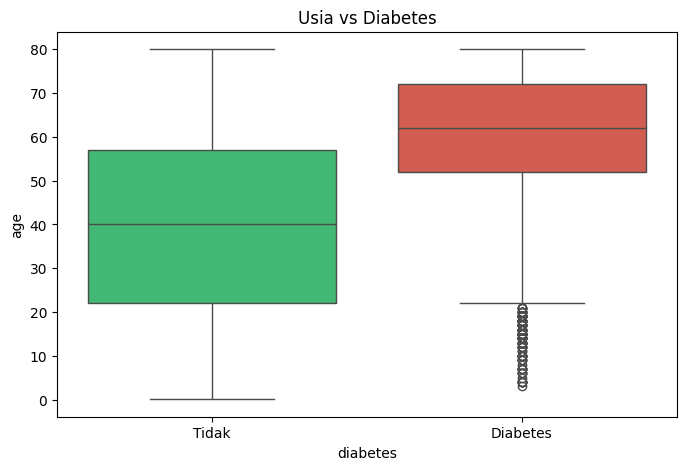

Usia rata-rata: Non-DM=39.9, DM=60.9


In [ ]:
# Q2: Usia vs Diabetes
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(x='diabetes', y='age', data=data, palette=['#2ecc71','#e74c3c'], ax=ax)
ax.set_title('Usia vs Diabetes'); ax.set_xticklabels(['Tidak','Diabetes'])
plt.show()
print(f"Usia rata-rata: Non-DM={data[data.diabetes==0].age.mean():.1f}, DM={data[data.diabetes==1].age.mean():.1f}")
# > Insight: Pasien diabetes cenderung berusia lebih tua (~60 vs ~40 tahun).

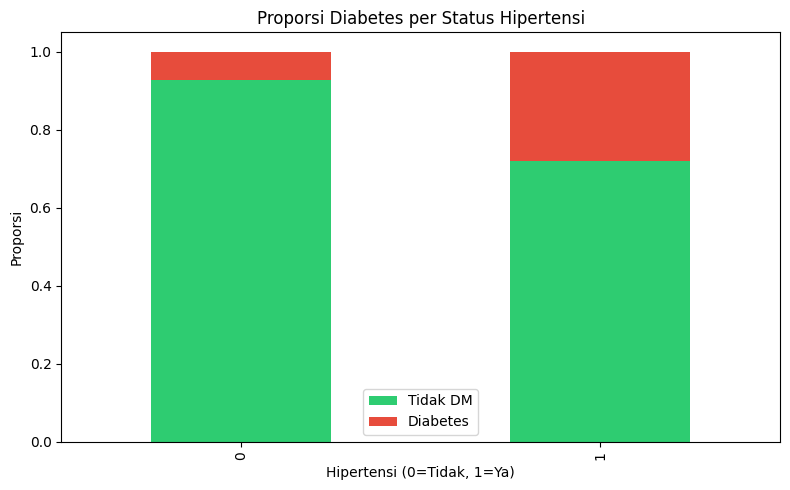

In [ ]:
# Q3: Hipertensi vs Diabetes
ct = pd.crosstab(data['hypertension'], data['diabetes'], normalize='index')
ct.plot(kind='bar', stacked=True, color=['#2ecc71','#e74c3c'], figsize=(8,5))
plt.title('Proporsi Diabetes per Status Hipertensi')
plt.xlabel('Hipertensi (0=Tidak, 1=Ya)'); plt.ylabel('Proporsi')
plt.legend(['Tidak DM','Diabetes']); plt.tight_layout(); plt.show()
# > Insight: Pasien dengan hipertensi memiliki prevalensi diabetes yang lebih tinggi.

 ---
 ## Fase 3 — Visualisasi & Explanatory Analysis
 > Kesimpulan EDA:
 > - Dataset sangat **imbalanced** (~91.5% non-diabetes vs ~8.5% diabetes)
 > - **BMI, usia, HbA1c, dan glukosa** adalah prediktor kuat diabetes
 > - Pasien dengan **hipertensi** memiliki risiko diabetes lebih tinggi
 > - Perlu penanganan class imbalance sebelum modeling

 ---
 ## Fase 4 — Preprocessing

 ### 4.1 Feature Engineering (sebelum split untuk konsistensi)

In [ ]:
data['age_group'] = pd.cut(data['age'], bins=[0,30,50,65,120], labels=[0,1,2,3]).astype(int)
data['bmi_category'] = pd.cut(data['bmi'], bins=[0,18.5,24.9,29.9,100], labels=[0,1,2,3]).astype(int)
data['glucose_risk'] = pd.cut(data['blood_glucose_level'], bins=[0,139,199,500], labels=[0,1,2]).astype(int)
data['hba1c_risk'] = pd.cut(data['HbA1c_level'], bins=[0,5.6,6.4,20], labels=[0,1,2]).astype(int)
data['comorbidity_score'] = data['hypertension'] + data['heart_disease']
data['metabolic_risk_index'] = (data['bmi'] * data['age']) / 100
print(f"Fitur setelah engineering: {data.columns.tolist()}")

Fitur setelah engineering: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'age_group', 'bmi_category', 'glucose_risk', 'hba1c_risk', 'comorbidity_score', 'metabolic_risk_index']


 ### 4.2 Split Data (Train 70% / Val 15% / Test 15%)

In [ ]:
X = data.drop('diabetes', axis=1)
y = data['diabetes']
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (67340, 14), Val: (14384, 14), Test: (14422, 14)


 ### 4.3 Normalisasi (fit pada train saja — no data leakage)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Scaler fit pada train, transform pada val & test. No data leakage.")

Scaler fit pada train, transform pada val & test. No data leakage.


 ---
 ## Fase 5 — Komparasi Model ML Tradisional (6 Sampler x 6 Model)

In [ ]:
sampling_methods = {
    "RandomOverSampler": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "EditedNN": EditedNearestNeighbours(n_neighbors=3),
    "TomekLinks": TomekLinks(),
    "SMOTE + ENN": SMOTEENN(random_state=42),
    "SMOTE + Tomek": SMOTETomek(random_state=42)
}
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=12),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42),
    "LGBM": LGBMClassifier(random_state=42, n_estimators=250, verbose=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=250, random_state=42),
    "XGB": XGBClassifier(random_state=42, eval_metric='logloss')
}

In [ ]:
cachedir = mkdtemp()
results = []
for mname, sampler in sampling_methods.items():
    print(f"\n-> {mname}")
    for mdl_name, mdl in models.items():
        print(f"   {mdl_name}...")
        clf = ImbPipeline([('sampler', sampler), ('clf', mdl)], memory=cachedir)
        clf.fit(X_train_scaled, y_train)
        yp = clf.predict(X_test_scaled)
        ypp = clf.predict_proba(X_test_scaled)[:,1] if hasattr(clf.named_steps['clf'],'predict_proba') else None
        results.append({
            "Sampling": mname, "Model": mdl_name,
            "Accuracy": accuracy_score(y_test, yp),
            "Precision": precision_score(y_test, yp, zero_division=0),
            "Recall": recall_score(y_test, yp, zero_division=0),
            "F1": f1_score(y_test, yp, zero_division=0),
            "AUC": roc_auc_score(y_test, ypp) if ypp is not None else np.nan,
            "MAE": mean_absolute_error(y_test, yp)
        })
        del clf, yp, ypp; gc.collect()
rmtree(cachedir)
results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n" + "="*70 + "\nHASIL KOMPARASI\n" + "="*70)
print(results_df.round(4).to_string(index=False))


-> RandomOverSampler
   Logistic Regression...
   Decision Tree...
   Random Forest...
   LGBM...
   Gradient Boosting...
   XGB...

-> SMOTE
   Logistic Regression...
   Decision Tree...
   Random Forest...
   LGBM...
   Gradient Boosting...
   XGB...

-> EditedNN
   Logistic Regression...
   Decision Tree...
   Random Forest...
   LGBM...
   Gradient Boosting...
   XGB...

-> TomekLinks
   Logistic Regression...
   Decision Tree...
   Random Forest...
   LGBM...
   Gradient Boosting...
   XGB...

-> SMOTE + ENN
   Logistic Regression...
   Decision Tree...
   Random Forest...
   LGBM...
   Gradient Boosting...
   XGB...

-> SMOTE + Tomek
   Logistic Regression...
   Decision Tree...
   Random Forest...
   LGBM...
   Gradient Boosting...
   XGB...

HASIL KOMPARASI
         Sampling               Model  Accuracy  Precision  Recall     F1    AUC    MAE
    SMOTE + Tomek   Gradient Boosting    0.9710     0.9402  0.7170 0.8136 0.9769 0.0290
       TomekLinks   Gradient Boosting    0.9712

 ---
 ## Fase 6 — Deep Learning Model (TensorFlow)
 Menggunakan **Functional API** + **Custom Layer** + **Custom Loss** + **Custom Callback**

In [ ]:
# === Custom Layer: Residual Dense Block ===
class ResidualDenseBlock(tf.keras.layers.Layer):
    def __init__(self, units, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.dense1 = tf.keras.layers.Dense(self.units, activation='relu')
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.drop1 = tf.keras.layers.Dropout(self.dropout_rate)
        self.dense2 = tf.keras.layers.Dense(self.units, activation='relu')
        self.bn2 = tf.keras.layers.BatchNormalization()
        if input_shape[-1] != self.units:
            self.proj = tf.keras.layers.Dense(self.units, use_bias=False)
        else:
            self.proj = None

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.bn1(x, training=training)
        x = self.drop1(x, training=training)
        x = self.dense2(x)
        x = self.bn2(x, training=training)
        shortcut = self.proj(inputs) if self.proj else inputs
        return tf.keras.activations.relu(x + shortcut)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.units, "dropout_rate": self.dropout_rate})
        return cfg

In [ ]:
# === Custom Loss: Focal Loss (bagus untuk imbalanced data) ===
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.75, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1-y_true) * tf.math.log(1-y_pred)
        p_t = y_true * y_pred + (1-y_true) * (1-y_pred)
        alpha_t = y_true * self.alpha + (1-y_true) * (1-self.alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1-p_t, self.gamma) * bce)

In [ ]:
# === Custom Callback: Print metrics setiap N epoch ===
class TrainingMonitor(tf.keras.callbacks.Callback):
    def __init__(self, print_every=10):
        super().__init__()
        self.print_every = print_every

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.print_every == 0:
            print(f"  Epoch {epoch+1}: loss={logs.get('loss',0):.4f}, "
                  f"val_loss={logs.get('val_loss',0):.4f}, "
                  f"val_acc={logs.get('val_accuracy',0):.4f}")

In [ ]:
# === Bangun Model: Functional API ===
n_features = X_train_scaled.shape[1]
inputs = tf.keras.Input(shape=(n_features,), name='input_features')
x = tf.keras.layers.Dense(128, activation='relu')(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = ResidualDenseBlock(64, dropout_rate=0.3, name='res_block_1')(x)
x = ResidualDenseBlock(32, dropout_rate=0.2, name='res_block_2')(x)
x = tf.keras.layers.Dense(16, activatixon='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(x)
dl_model = tf.keras.Model(inputs=inputs, outputs=outputs, name='diabetes_classifier')
dl_model.summary()

Model: "diabetes_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_1                     │ (None, 64)             │        21,120 │
│ (ResidualDenseBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_2                     │ (None, 32)             │         5,440 │
│ (ResidualDenseBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,537 (115.38 KB)

 Trainable params: 28,897 (112.88 KB)

 Non-trainable params: 640 (2.50 KB)

 ---
 ## Fase 7 — Training dengan tf.GradientTape + TensorBoard

In [ ]:
# Hitung class weights
neg, pos = np.bincount(y_train.values)
class_weight = {0: 1.0, 1: neg / pos}
print(f"Class weights: {class_weight}")

# Buat sample weights
sample_weights = np.where(y_train.values == 1, class_weight[1], class_weight[0])

Class weights: {0: 1.0, 1: np.float64(10.334792122538293)}


In [ ]:
# === Custom Training Loop dengan tf.GradientTape ===
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
focal_loss = FocalLoss(gamma=2.0, alpha=0.75)
train_acc_metric = tf.keras.metrics.BinaryAccuracy()
val_acc_metric = tf.keras.metrics.BinaryAccuracy()
train_loss_metric = tf.keras.metrics.Mean()

# TensorBoard setup
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(log_dir, exist_ok=True)
train_summary_writer = tf.summary.create_file_writer(os.path.join(log_dir, 'train'))
val_summary_writer = tf.summary.create_file_writer(os.path.join(log_dir, 'validation'))

# Datasets
BATCH_SIZE = 256
EPOCHS = 80
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train_scaled.astype('float32'), y_train.values.astype('float32'),
     sample_weights.astype('float32'))
).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val_scaled.astype('float32'), y_val.values.astype('float32'))
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
best_val_loss = float('inf')
patience, wait = 15, 0
best_weights = None

for epoch in range(EPOCHS):
    # --- Training ---
    train_acc_metric.reset_state(); train_loss_metric.reset_state()
    for x_batch, y_batch, w_batch in train_ds:
        with tf.GradientTape() as tape:
            preds = dl_model(x_batch, training=True)
            loss = focal_loss(tf.expand_dims(y_batch, -1), preds)
            loss = loss * tf.reduce_mean(w_batch)
        grads = tape.gradient(loss, dl_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, dl_model.trainable_variables))
        train_acc_metric.update_state(y_batch, tf.squeeze(preds))
        train_loss_metric.update_state(loss)

    # --- Validation ---
    val_acc_metric.reset_state(); val_losses = []
    for x_batch, y_batch in val_ds:
        preds = dl_model(x_batch, training=False)
        vl = focal_loss(tf.expand_dims(y_batch, -1), preds)
        val_losses.append(float(vl))
        val_acc_metric.update_state(y_batch, tf.squeeze(preds))
    val_loss = np.mean(val_losses)

    # TensorBoard logging
    with train_summary_writer.as_default():
        tf.summary.scalar('loss', train_loss_metric.result(), step=epoch)
        tf.summary.scalar('accuracy', train_acc_metric.result(), step=epoch)
    with val_summary_writer.as_default():
        tf.summary.scalar('loss', val_loss, step=epoch)
        tf.summary.scalar('accuracy', val_acc_metric.result(), step=epoch)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - loss: {train_loss_metric.result():.4f} - "
              f"acc: {train_acc_metric.result():.4f} - val_loss: {val_loss:.4f} - "
              f"val_acc: {val_acc_metric.result():.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = dl_model.get_weights()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

if best_weights:
    dl_model.set_weights(best_weights)
    print("Best weights restored.")

Epoch 10/80 - loss: 0.0224 - acc: 0.9563 - val_loss: 0.0115 - val_acc: 0.9620
Epoch 20/80 - loss: 0.0218 - acc: 0.9558 - val_loss: 0.0114 - val_acc: 0.9614
Epoch 30/80 - loss: 0.0209 - acc: 0.9598 - val_loss: 0.0112 - val_acc: 0.9606
Epoch 40/80 - loss: 0.0209 - acc: 0.9589 - val_loss: 0.0114 - val_acc: 0.9653
Early stopping at epoch 45
Best weights restored.


 ---
 ## Fase 8 — Evaluasi Model
 Target: **Accuracy ≥ 85%** dan **MAE ≤ 0.02**

In [ ]:
# Evaluasi Deep Learning Model
y_pred_prob = dl_model.predict(X_test_scaled.astype('float32')).flatten()
y_pred_dl = (y_pred_prob >= 0.5).astype(int)

acc_dl = accuracy_score(y_test, y_pred_dl)
mae_dl = mean_absolute_error(y_test, y_pred_dl)
prec_dl = precision_score(y_test, y_pred_dl, zero_division=0)
rec_dl = recall_score(y_test, y_pred_dl, zero_division=0)
f1_dl = f1_score(y_test, y_pred_dl, zero_division=0)
auc_dl = roc_auc_score(y_test, y_pred_prob)

print("="*50)
print("EVALUASI MODEL DEEP LEARNING (Test Set)")
print("="*50)
print(f"✅ Accuracy : {acc_dl:.4f} {'✓' if acc_dl >= 0.85 else '✗'} (target ≥ 0.85)")
print(f"✅ MAE      : {mae_dl:.4f} {'✓' if mae_dl <= 0.02 else '✗'} (target ≤ 0.02)")
print(f"   Precision: {prec_dl:.4f}")
print(f"   Recall   : {rec_dl:.4f}")
print(f"   F1-Score : {f1_dl:.4f}")
print(f"   AUC-ROC  : {auc_dl:.4f}")
print("\n" + classification_report(y_test, y_pred_dl, target_names=['Tidak DM','Diabetes']))

451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
EVALUASI MODEL DEEP LEARNING (Test Set)
✅ Accuracy : 0.9615 ✓ (target ≥ 0.85)
✅ MAE      : 0.0385 ✗ (target ≤ 0.02)
   Precision: 0.7955
   Recall   : 0.7586
   F1-Score : 0.7767
   AUC-ROC  : 0.9746

              precision    recall  f1-score   support

    Tidak DM       0.98      0.98      0.98     13150
    Diabetes       0.80      0.76      0.78      1272

    accuracy                           0.96     14422
   macro avg       0.89      0.87      0.88     14422
weighted avg       0.96      0.96      0.96     14422



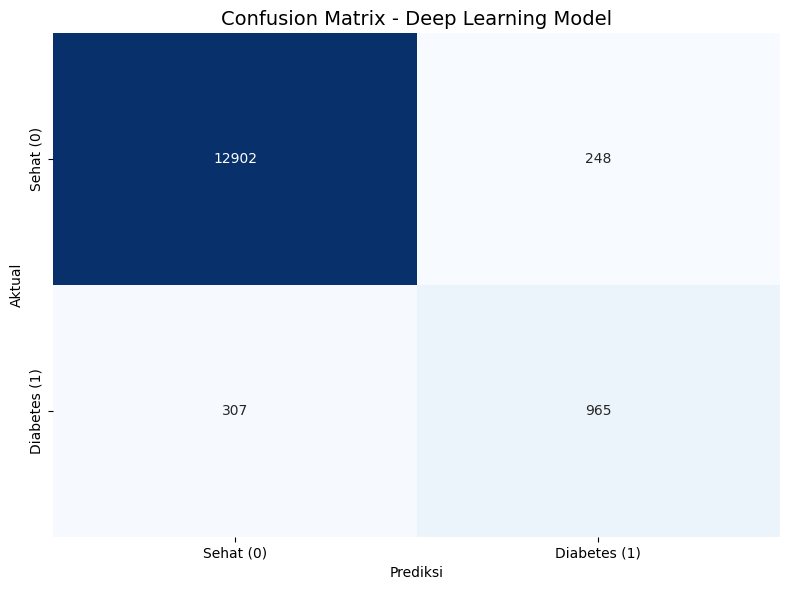

TN=12902, FP=248, FN=307, TP=965


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dl)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sehat (0)','Diabetes (1)'],
            yticklabels=['Sehat (0)','Diabetes (1)'])
plt.title('Confusion Matrix - Deep Learning Model', fontsize=14)
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.tight_layout(); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

 ---
 ## Fase 9 — Export Model

In [ ]:
# Simpan model TensorFlow
dl_model.save('diabetes_model.keras')
print("Model disimpan: diabetes_model.keras")

# Simpan scaler
joblib.dump(scaler, 'scaler.joblib')
print("Scaler disimpan: scaler.joblib")

# Simpan metadata
metadata = {
    "feature_names": X.columns.tolist(),
    "categorical_mappings": {
        "gender": {'Female': 0, 'Male': 1, 'Other': 2},
        "smoking_history": {'never': 0, 'No Info': 1, 'current': 2, 'former': 3, 'ever': 4, 'not current': 5}
    },
    "feature_engineering": {
        "age_group": {"bins": [0,30,50,65,120], "labels": [0,1,2,3]},
        "bmi_category": {"bins": [0,18.5,24.9,29.9,100], "labels": [0,1,2,3]},
        "glucose_risk": {"bins": [0,139,199,500], "labels": [0,1,2]},
        "hba1c_risk": {"bins": [0,5.6,6.4,20], "labels": [0,1,2]}
    }
}
with open('metadata.json','w') as f:
    json.dump(metadata, f, indent=2)
print("Metadata disimpan: metadata.json")

Model disimpan: diabetes_model.keras
Scaler disimpan: scaler.joblib
Metadata disimpan: metadata.json


 ### Kode Inference Sederhana